In [29]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 150)


In [30]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [31]:
df = pd.read_csv("IMDB Dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />Thi...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. Thi...",positive


In [32]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing values:
 review       0
sentiment    0
dtype: int64

Duplicate rows: 418


In [28]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Shape after dropping duplicates: (49582, 5)


/tmp/ipykernel_503/873341112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", palette="Set2")


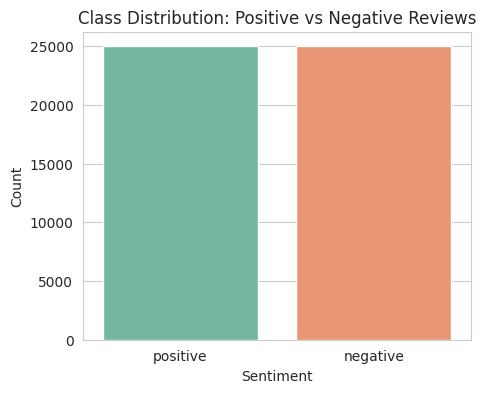

,count
sentiment,
positive,25000
negative,25000


In [33]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="sentiment", palette="Set2")
plt.title("Class Distribution: Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

df['sentiment'].value_counts()


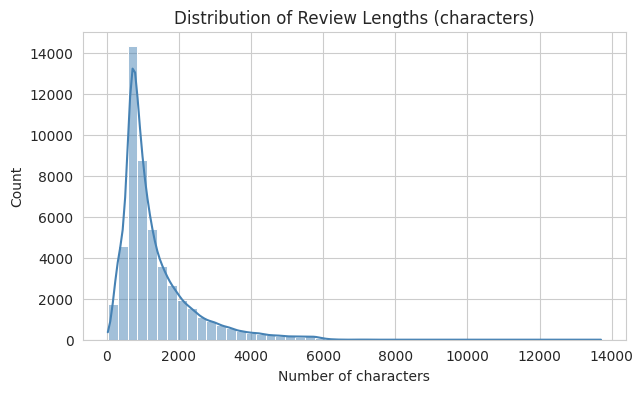

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


In [34]:
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(7,4))
sns.histplot(df['review_length'], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Review Lengths (characters)")
plt.xlabel("Number of characters")
plt.show()

df['review_length'].describe()


In [35]:
for i in [0, 1]:
    print(f"--- Review {i} (sentiment: {df['sentiment'][i]}) ---")
    print(df['review'][i][:400], "...\n")


--- Review 0 (sentiment: positive) ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to ...

--- Review 1 (sentiment: positive) ---
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the referen ...



In [36]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean, tokenize, remove stop-words, and lemmatize a piece of raw text."""
    text = text.lower()


    text = re.sub(r'<.*?>', ' ', text)


    text = re.sub(r'[^a-z\s]', ' ', text)


    tokens = word_tokenize(text)


    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]


    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)


In [37]:
sample_raw = df['review'][0]
sample_clean = preprocess_text(sample_raw)

print("RAW:\n", sample_raw[:300], "...\n")
print("CLEANED:\n", sample_clean[:300], "...")


RAW:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru ...

CLEANED:
 one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called nickname given oswald maximum security state penitenta ...


In [15]:
df['clean_review'] = df['review'].apply(preprocess_text)
df[['review', 'clean_review', 'sentiment']].head()


,review,clean_review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust...,positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",wonderful little production filming technique unassuming old time bbc fashion give comforting sometimes discomforting sense realism entire piece a...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",thought wonderful way spend time hot summer weekend sitting air conditioned theater watching light hearted comedy plot simplistic dialogue witty c...,positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />Thi...,basically family little boy jake think zombie closet parent fighting time movie slower soap opera suddenly jake decides become rambo kill zombie f...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. Thi...",petter mattei love time money visually stunning film watch mattei offer vivid portrait human relation movie seems telling money power success peop...,positive


In [16]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df[['sentiment', 'label']].drop_duplicates()


,sentiment,label
0,positive,1
3,negative,0


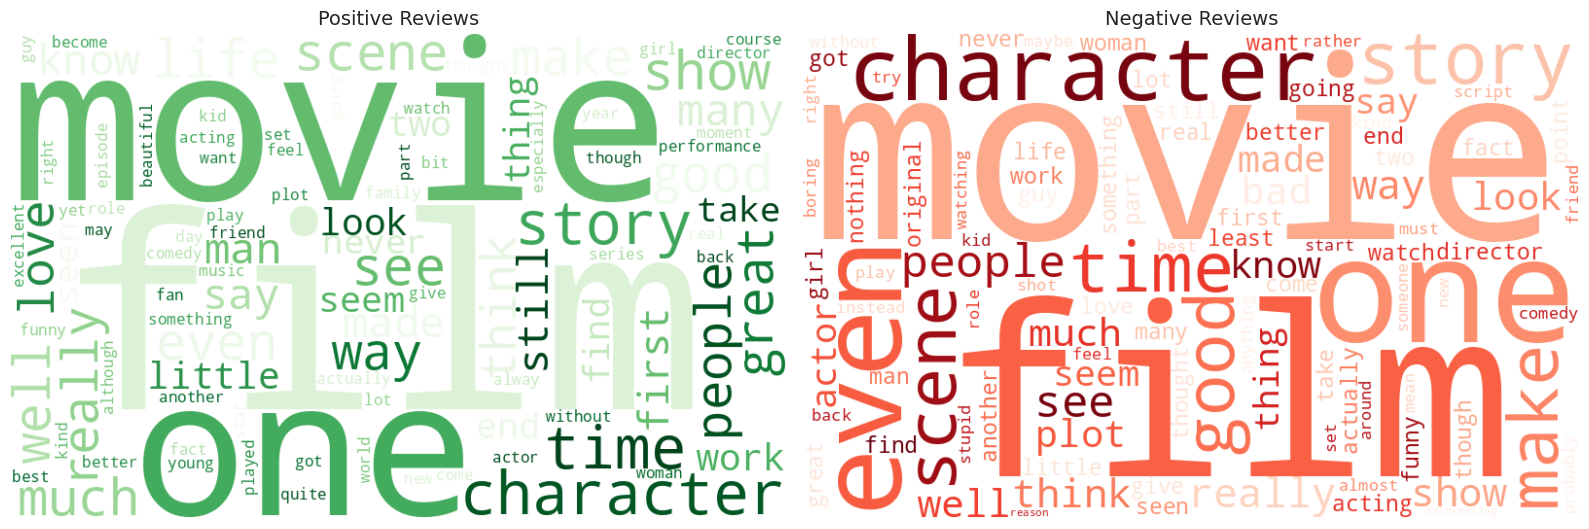

In [17]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title, cmap in zip(
        axes, [1, 0], ["Positive Reviews", "Negative Reviews"], ["Greens", "Reds"]):
    text_blob = " ".join(df.loc[df['label'] == label, 'clean_review'].sample(
        min(5000, (df['label'] == label).sum()), random_state=42))
    wc = WordCloud(width=800, height=500, background_color="white",
                   colormap=cmap, max_words=100).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [18]:
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 39665
Test size : 9917


In [19]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF testing matrix shape :", X_test_tfidf.shape)


TF-IDF training matrix shape: (39665, 10000)
TF-IDF testing matrix shape : (9917, 10000)


In [20]:
feature_names = tfidf.get_feature_names_out()
print("Sample vocabulary terms:", feature_names[1000:1020])


Sample vocabulary terms: ['brain' 'brainless' 'branagh' 'branch' 'brand' 'brando' 'brat' 'brave'
 'bravo' 'brazil' 'brazilian' 'bread' 'break' 'breakdown' 'breakfast'
 'breaking' 'breast' 'breath' 'breathe' 'breathing']


In [21]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_preds)

print(f"Naive Bayes Accuracy: {nb_acc:.4f}\n")
print(classification_report(y_test, nb_preds, target_names=['negative', 'positive']))


Naive Bayes Accuracy: 0.8683

              precision    recall  f1-score   support

    negative       0.88      0.85      0.87      4940
    positive       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



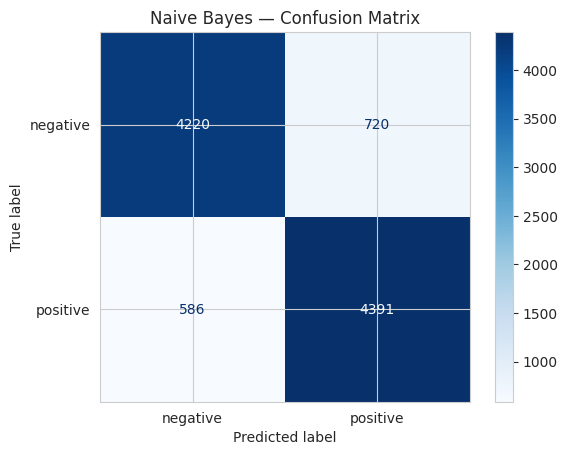

In [22]:
cm_nb = confusion_matrix(y_test, nb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['negative', 'positive'])
disp.plot(cmap="Blues", values_format='d')
plt.title("Naive Bayes — Confusion Matrix")
plt.show()


In [23]:
svm_model = LinearSVC(random_state=42, max_iter=5000)
svm_model.fit(X_train_tfidf, y_train)

svm_preds = svm_model.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_preds)

print(f"SVM Accuracy: {svm_acc:.4f}\n")
print(classification_report(y_test, svm_preds, target_names=['negative', 'positive']))


SVM Accuracy: 0.8902

              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      4940
    positive       0.89      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



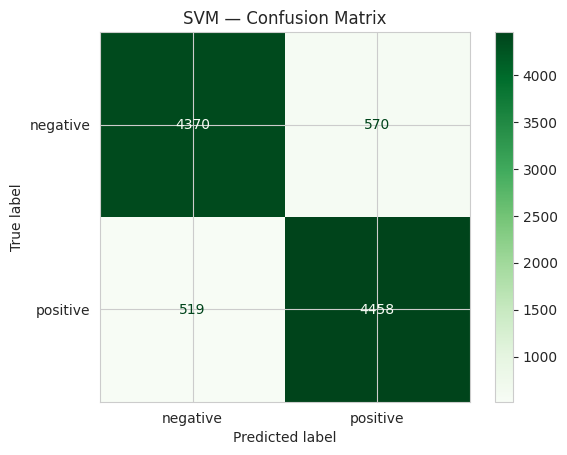

In [24]:
cm_svm = confusion_matrix(y_test, svm_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['negative', 'positive'])
disp.plot(cmap="Greens", values_format='d')
plt.title("SVM — Confusion Matrix")
plt.show()


In [25]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM"],
    "Accuracy": [nb_acc, svm_acc]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

results


,Model,Accuracy
0,SVM,0.890189
1,Naive Bayes,0.868307


/tmp/ipykernel_503/3920957971.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="Accuracy", palette="viridis")


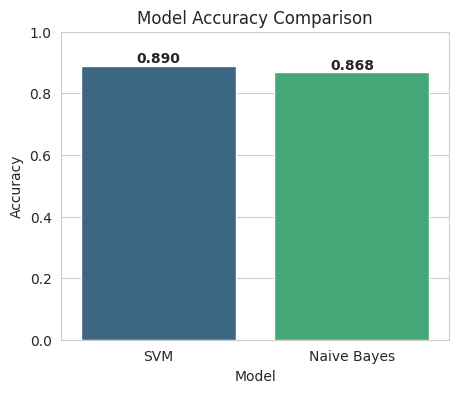

Best performing model: SVM


In [26]:
plt.figure(figsize=(5,4))
sns.barplot(data=results, x="Model", y="Accuracy", palette="viridis")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
for i, acc in enumerate(results["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.3f}", ha='center', fontweight='bold')
plt.show()

best_model_name = results.iloc[0]["Model"]
best_model = svm_model if best_model_name == "SVM" else nb_model
print(f"Best performing model: {best_model_name}")


In [27]:
def predict_sentiment(raw_text, model=best_model, vectorizer=tfidf):
    cleaned = preprocess_text(raw_text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return "Positive" if pred == 1 else "Negative"

sample_reviews = [
    "This movie was an absolute masterpiece, the acting and story blew me away!",
    "Waste of time. Boring plot, terrible acting, I want my two hours back.",
    "It was okay, not great but not terrible either, pretty average film overall.",
]

for review in sample_reviews:
    print(f"Review : {review}")
    print(f"Predicted Sentiment: {predict_sentiment(review)}\n")


Review : This movie was an absolute masterpiece, the acting and story blew me away!
Predicted Sentiment: Positive

Review : Waste of time. Boring plot, terrible acting, I want my two hours back.
Predicted Sentiment: Negative

Review : It was okay, not great but not terrible either, pretty average film overall.
Predicted Sentiment: Negative

